<a href="https://colab.research.google.com/github/Jitheshkumar08/deep-learning/blob/main/Deep_Learning_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Task 2
## Part 1 – CNN Image Classification on Fashion-MNIST

In [3]:
# Cell 1 – Install dependencies
!pip install torch torchvision matplotlib scikit-learn tqdm tensorflow --quiet
print("All packages installed.")

All packages installed.


In [4]:
# Cell 2 – Imports & device setup
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Helper: display image grid ──────────────────────────────────────────────
def display_images_grid(images, title=None, num_images=16):
    fig = plt.figure(figsize=(8, 8))
    rows_cols = int(np.sqrt(num_images))
    for i in range(num_images):
        ax = fig.add_subplot(rows_cols, rows_cols, i + 1, xticks=[], yticks=[])
        if images.shape[1] == 1:
            ax.imshow(images[i].squeeze(), cmap='gray')
        else:
            ax.imshow(np.transpose(images[i].cpu().detach().numpy(), (1, 2, 0)))
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# ── Helper: plot training metrics ───────────────────────────────────────────
def plot_metrics(train_losses, train_accuracies,
                 val_losses=None, val_accuracies=None,
                 title='Training and Validation Metrics'):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b', label='Training loss')
    if val_losses:
        plt.plot(epochs, val_losses, 'r', label='Validation loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b', label='Training accuracy')
    if val_accuracies:
        plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.suptitle(title, y=1.02, fontsize=14)
    plt.show()

print("Libraries imported, device set, and helper functions defined.")

Using device: cuda
Libraries imported, device set, and helper functions defined.


In [5]:
# Cell 3 – Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # Normalize to [-1, 1]
])
print("Data transformations defined.")

Data transformations defined.


In [6]:
# Cell 4 – Load Fashion-MNIST
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

batch_size   = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Batch size       : {batch_size}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.2MB/s]

Training samples : 60000
Test samples     : 10000
Batch size       : 64


Labels: Shirt        Sandal       Pullover     Pullover     Pullover     Shirt        Dress        Pullover    


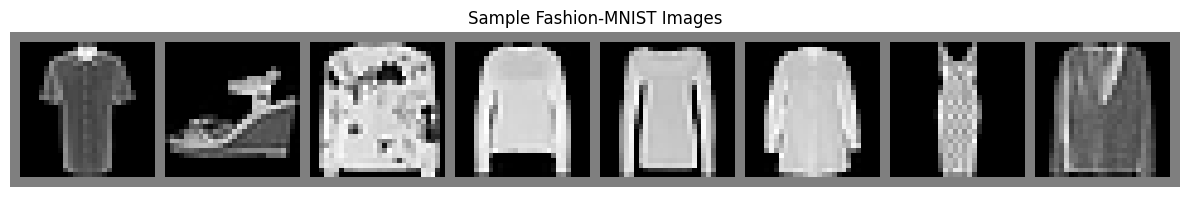

Sample images displayed.


In [7]:
# Cell 5 – Visualise sample images
classes   = ('T-shirt/top','Trouser','Pullover','Dress','Coat',
             'Sandal','Shirt','Sneaker','Bag','Ankle Boot')

dataiter = iter(train_loader)
images, labels = next(dataiter)

# Un-normalise for display
def unnorm(img):
    return img / 2 + 0.5

print('Labels:', ' '.join(f'{classes[labels[j]]:12s}' for j in range(8)))
grid = torchvision.utils.make_grid(images[:8])
plt.figure(figsize=(12, 3))
plt.imshow(np.transpose(unnorm(grid).numpy(), (1, 2, 0)), cmap='gray')
plt.axis('off')
plt.title('Sample Fashion-MNIST Images')
plt.tight_layout()
plt.show()
print("Sample images displayed.")

In [8]:
# Cell 6 – Custom CNN architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # Block 1: 1x28x28 -> 32x14x14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 2: 32x14x14 -> 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Quick shape sanity-check
_dummy = torch.zeros(1, 1, 28, 28)
_model = CustomCNN()
print("Output shape:", _model(_dummy).shape)   # should be (1, 10)
print("CustomCNN architecture defined.")

Output shape: torch.Size([1, 10])
CustomCNN architecture defined.


In [9]:
# Cell 7 – Instantiate CustomCNN, loss, and optimiser
model     = CustomCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model:")
print(model)
print("\nLoss function : CrossEntropyLoss")
print("Optimiser     : Adam  lr=0.001")

Model:
CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=3136, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Loss function : CrossEntropyLoss
Optimiser     : Adam  lr=0.001


In [10]:
# Cell 8 – train_model helper function
def train_model(model, criterion, optimizer, train_loader, test_loader, num_epochs=10):
    train_losses, train_accuracies = [], []
    val_losses,   val_accuracies   = [], []

    for epoch in range(num_epochs):
        # ── Training ───────────────────────────────────────────
        model.train()
        running_loss  = 0.0
        correct_train = 0
        total_train   = 0

        for inputs, labels in tqdm(train_loader,
                                   desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss  += loss.item() * inputs.size(0)
            _, predicted   = torch.max(outputs, 1)
            total_train   += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc  = 100.0 * correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # ── Validation ─────────────────────────────────────────
        model.eval()
        running_val_loss = 0.0
        correct_val      = 0
        total_val        = 0

        with torch.no_grad():
            for inputs, labels in tqdm(test_loader,
                                       desc=f"Epoch {epoch+1}/{num_epochs} [Val]  "):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs  = model(inputs)
                loss     = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val   += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        epoch_val_acc  = 100.0 * correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

print("train_model() helper defined.")

train_model() helper defined.


In [11]:
# Cell 9 – Train CustomCNN
num_epochs_custom_cnn = 10
(custom_cnn_train_losses, custom_cnn_train_accuracies,
 custom_cnn_val_losses,   custom_cnn_val_accuracies) = train_model(
    model, criterion, optimizer,
    train_loader, test_loader,
    num_epochs=num_epochs_custom_cnn)

print("\nCustom CNN training complete.")

Epoch 1/10 [Val]  : 100%|██████████| 157/157 [00:02<00:00, 73.12it/s]


Epoch   1/10 | Train Loss: 0.4739  Acc: 82.78% | Val Loss: 0.3314  Acc: 87.95%


Epoch 2/10 [Val]  : 100%|██████████| 157/157 [00:02<00:00, 74.40it/s]


Epoch   2/10 | Train Loss: 0.3212  Acc: 88.40% | Val Loss: 0.2908  Acc: 89.44%


Epoch 3/10 [Val]  : 100%|██████████| 157/157 [00:02<00:00, 75.49it/s]


...

Epoch   8/10 | Train Loss: 0.1812  Acc: 93.22% | Val Loss: 0.2261  Acc: 91.91%


Epoch 9/10 [Val]  : 100%|██████████| 157/157 [00:02<00:00, 52.44it/s]


Epoch   9/10 | Train Loss: 0.1677  Acc: 93.75% | Val Loss: 0.2299  Acc: 91.71%


Epoch 10/10 [Val]  : 100%|██████████| 157/157 [00:02<00:00, 72.04it/s]

Epoch  10/10 | Train Loss: 0.1561  Acc: 94.28% | Val Loss: 0.2432  Acc: 91.58%

Custom CNN training complete.


In [12]:
# Cell 10 – Evaluate CustomCNN
def evaluate_model(model, criterion, data_loader):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / len(data_loader.dataset)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

test_loss_custom_cnn, test_accuracy_custom_cnn = evaluate_model(
    model, criterion, test_loader)
print(f"\nCustom CNN  →  Test Loss: {test_loss_custom_cnn:.4f} | "
      f"Test Accuracy: {test_accuracy_custom_cnn:.2f}%")

Evaluating: 100%|██████████| 157/157 [00:02<00:00, 58.17it/s]


Custom CNN  →  Test Loss: 0.2432 | Test Accuracy: 91.58%


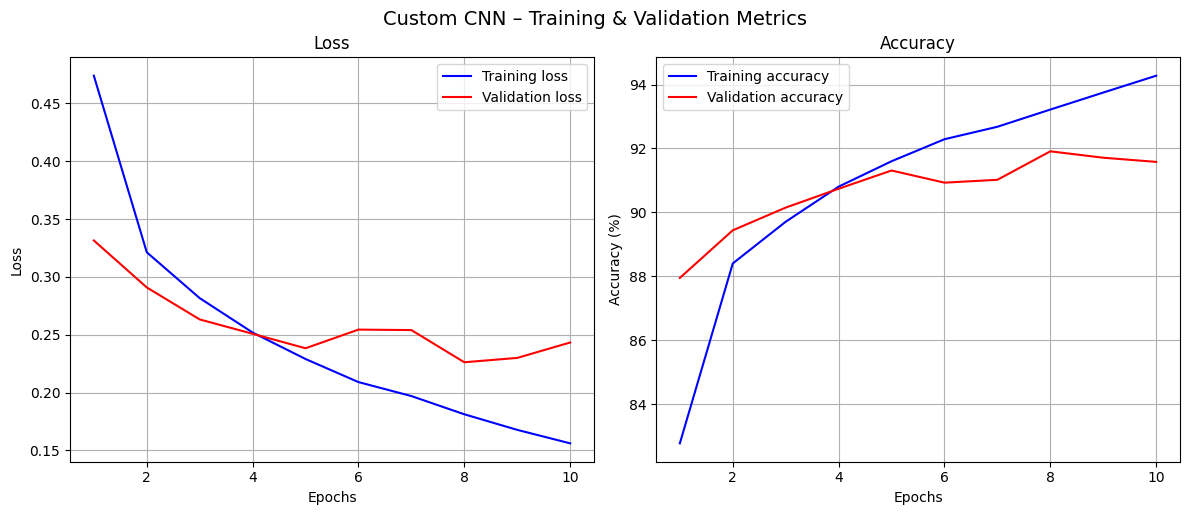

In [13]:
# Cell 11 – Plot CustomCNN metrics
plot_metrics(custom_cnn_train_losses, custom_cnn_train_accuracies,
             custom_cnn_val_losses,   custom_cnn_val_accuracies,
             title='Custom CNN – Training & Validation Metrics')

In [14]:
# Cell 12 – Print epoch-by-epoch summary (CustomCNN)
print("Custom CNN – Training Metrics")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>12} {'Val Loss':>10} {'Val Acc':>10}")
for i in range(len(custom_cnn_train_losses)):
    print(f"{i+1:>6} {custom_cnn_train_losses[i]:>12.4f} "
          f"{custom_cnn_train_accuracies[i]:>11.2f}% "
          f"{custom_cnn_val_losses[i]:>10.4f} "
          f"{custom_cnn_val_accuracies[i]:>9.2f}%")

print(f"\nFinal Test Loss     : {test_loss_custom_cnn:.4f}")
print(f"Final Test Accuracy : {test_accuracy_custom_cnn:.2f}%")

Custom CNN – Training Metrics
 Epoch   Train Loss    Train Acc   Val Loss    Val Acc
     1       0.4739       82.78%     0.3314     87.95%
     2       0.3212       88.40%     0.2908     89.44%
     3       0.2816       89.71%     0.2632     90.15%
     4       0.2519       90.81%     0.2508     90.74%
     5       0.2290       91.60%     0.2383     91.31%
     6       0.2090       92.29%     0.2544     90.93%
     7       0.1969       92.68%     0.2540     91.02%
     8       0.1812       93.22%     0.2261     91.91%
     9       0.1677       93.75%     0.2299     91.71%
    10       0.1561       94.28%     0.2432     91.58%

Final Test Loss     : 0.2432
Final Test Accuracy : 91.58%


## Part 2 – Transfer Learning with ResNet-18

In [15]:
# Cell 13 – Load & adapt pre-trained ResNet-18
import torchvision.models as models

resnet_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Adapt conv1 for 1-channel (grayscale) input
resnet_model.conv1 = nn.Conv2d(
    1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Replace final FC layer for 10-class output
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)

resnet_model = resnet_model.to(device)
print("Pre-trained ResNet-18 loaded and adapted for Fashion-MNIST.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 115MB/s]


Pre-trained ResNet-18 loaded and adapted for Fashion-MNIST.


In [16]:
# Cell 14 – Freeze base layers, unfreeze final FC
for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Trainable parameters after freezing: {trainable_params:,}")

criterion_resnet  = nn.CrossEntropyLoss()
optimizer_resnet  = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=0.001)

print("ResNet-18 base layers frozen; only the final FC layer is trainable.")
print("Loss and optimiser defined.")

Trainable parameters after freezing: 5,130
ResNet-18 base layers frozen; only the final FC layer is trainable.
Loss and optimiser defined.


In [17]:
# Cell 15 – Train ResNet-18 (feature extraction, 4 epochs)
num_epochs_resnet = 4
(resnet_train_losses, resnet_train_accuracies,
 resnet_val_losses,   resnet_val_accuracies) = train_model(
    resnet_model, criterion_resnet, optimizer_resnet,
    train_loader, test_loader,
    num_epochs=num_epochs_resnet)

print("\nResNet-18 (frozen) training complete.")

Epoch 1/4 [Val]  : 100%|██████████| 157/157 [00:03<00:00, 45.69it/s]


Epoch   1/4 | Train Loss: 1.1591  Acc: 59.13% | Val Loss: 1.0109  Acc: 64.55%


Epoch 2/4 [Val]  : 100%|██████████| 157/157 [00:03<00:00, 45.53it/s]


Epoch   2/4 | Train Loss: 1.0095  Acc: 64.20% | Val Loss: 0.9690  Acc: 65.84%


Epoch 3/4 [Val]  : 100%|██████████| 157/157 [00:03<00:00, 47.69it/s]


Epoch   3/4 | Train Loss: 0.9900  Acc: 64.31% | Val Loss: 0.9674  Acc: 65.55%


Epoch 4/4 [Val]  : 100%|██████████| 157/157 [00:03<00:00, 47.39it/s]

Epoch   4/4 | Train Loss: 0.9805  Acc: 64.81% | Val Loss: 0.9632  Acc: 66.70%

ResNet-18 (frozen) training complete.


In [18]:
# Cell 16 – Evaluate ResNet-18
test_loss_resnet, test_accuracy_resnet = evaluate_model(
    resnet_model, criterion_resnet, test_loader)
print(f"\nResNet-18  →  Test Loss: {test_loss_resnet:.4f} | "
      f"Test Accuracy: {test_accuracy_resnet:.2f}%")

Evaluating: 100%|██████████| 157/157 [00:03<00:00, 46.17it/s]


ResNet-18  →  Test Loss: 0.9632 | Test Accuracy: 66.70%


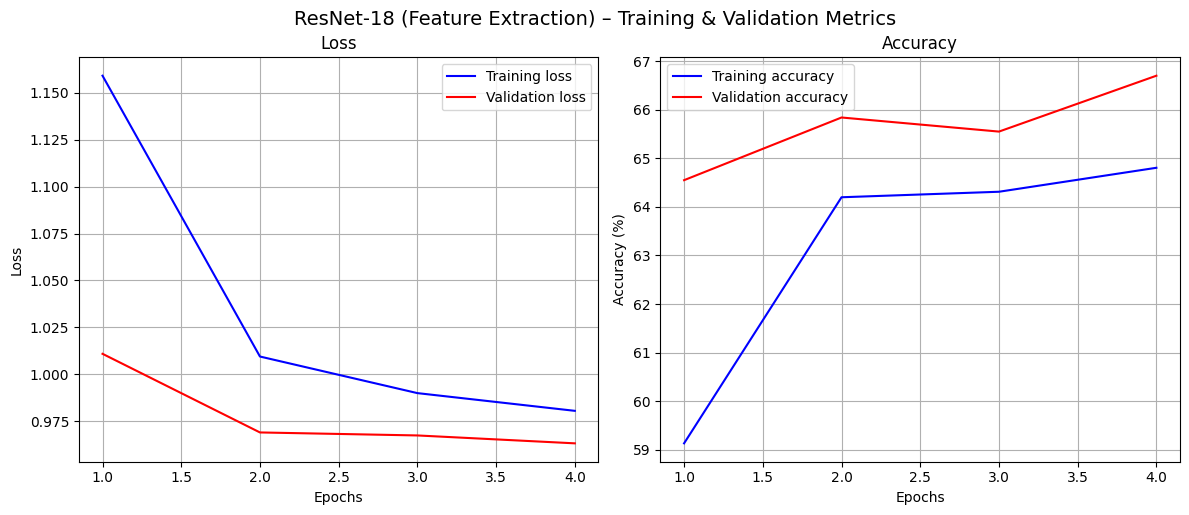

In [19]:
# Cell 17 – Plot ResNet-18 metrics
plot_metrics(resnet_train_losses, resnet_train_accuracies,
             resnet_val_losses,   resnet_val_accuracies,
             title='ResNet-18 (Feature Extraction) – Training & Validation Metrics')

In [20]:
# Cell 18 – Compare both CNN models
print("=" * 60)
print(f"{'Model':<20} {'Test Loss':>10} {'Test Accuracy':>15}")
print("-" * 60)
print(f"{'Custom CNN':<20} {test_loss_custom_cnn:>10.4f} {test_accuracy_custom_cnn:>14.2f}%")
print(f"{'ResNet-18':<20} {test_loss_resnet:>10.4f} {test_accuracy_resnet:>14.2f}%")
print("=" * 60)

Model                 Test Loss   Test Accuracy
------------------------------------------------------------
Custom CNN               0.2432          91.58%
ResNet-18                0.9632          66.70%


## Part 3 – Sentiment Analysis with RNN, LSTM, GRU (IMDB)

In [21]:
# Cell 19 – Load & preprocess IMDB dataset
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocabulary_size   = 10000
max_sequence_length = 200

(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = imdb.load_data(
    num_words=vocabulary_size)

X_train_imdb = pad_sequences(X_train_imdb, maxlen=max_sequence_length)
X_test_imdb  = pad_sequences(X_test_imdb,  maxlen=max_sequence_length)

print(f"Training data shape : {X_train_imdb.shape}")
print(f"Test data shape     : {X_test_imdb.shape}")
print("IMDB dataset loaded and padded.")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape : (25000, 200)
Test data shape     : (25000, 200)
IMDB dataset loaded and padded.


In [22]:
# Cell 20 – Define Simple RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

def build_rnn_model(cell_type='SimpleRNN'):
    model = Sequential(name=cell_type + '_model')
    model.add(Embedding(input_dim=vocabulary_size, output_dim=128,
                        input_length=max_sequence_length))
    if cell_type == 'SimpleRNN':
        model.add(SimpleRNN(128))
    elif cell_type == 'LSTM':
        model.add(LSTM(128))
    elif cell_type == 'GRU':
        model.add(GRU(128))
    model.add(Dense(1, activation='sigmoid'))
    return model

rnn_model  = build_rnn_model('SimpleRNN')
lstm_model = build_rnn_model('LSTM')
gru_model  = build_rnn_model('GRU')

rnn_model.summary()
lstm_model.summary()
gru_model.summary()
print("SimpleRNN, LSTM, GRU models defined.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

SimpleRNN, LSTM, GRU models defined.


In [23]:
# Cell 21 – Compile all three models
rnn_model.compile( optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.compile( optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("All three models compiled.")

All three models compiled.


In [24]:
# Cell 22 – Train Simple RNN
history_rnn = rnn_model.fit(
    X_train_imdb, y_train_imdb,
    epochs=5, batch_size=32,
    validation_data=(X_test_imdb, y_test_imdb))
print("Simple RNN training complete.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.6330 - loss: 0.6268 - val_accuracy: 0.6186 - val_loss: 0.6459
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6725 - loss: 0.6035 - val_accuracy: 0.6503 - val_loss: 0.6101
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7038 - loss: 0.5602 - val_accuracy: 0.6442 - val_loss: 0.6196
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7278 - loss: 0.5274 - val_accuracy: 0.6811 - val_loss: 0.6149
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7882 - loss: 0.4508 - val_accuracy: 0.6823 - val_loss: 0.6048
Simple RNN training complete.


In [25]:
# Cell 23 – Train LSTM
history_lstm = lstm_model.fit(
    X_train_imdb, y_train_imdb,
    epochs=5, batch_size=32,
    validation_data=(X_test_imdb, y_test_imdb))
print("LSTM training complete.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.7270 - loss: 0.5379 - val_accuracy: 0.8227 - val_loss: 0.4128
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8728 - loss: 0.3104 - val_accuracy: 0.8672 - val_loss: 0.3250
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9206 - loss: 0.2005 - val_accuracy: 0.8741 - val_loss: 0.3041
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9502 - loss: 0.1399 - val_accuracy: 0.8745 - val_loss: 0.3387
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9685 - loss: 0.0895 - val_accuracy: 0.8677 - val_loss: 0.4156
LSTM training complete.


In [26]:
# Cell 24 – Train GRU
history_gru = gru_model.fit(
    X_train_imdb, y_train_imdb,
    epochs=5, batch_size=32,
    validation_data=(X_test_imdb, y_test_imdb))
print("GRU training complete.")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.7816 - loss: 0.4554 - val_accuracy: 0.8403 - val_loss: 0.3759
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9063 - loss: 0.2383 - val_accuracy: 0.8890 - val_loss: 0.2758
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9485 - loss: 0.1444 - val_accuracy: 0.8752 - val_loss: 0.3162
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9724 - loss: 0.0811 - val_accuracy: 0.8702 - val_loss: 0.4084
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9843 - loss: 0.0477 - val_accuracy: 0.8606 - val_loss: 0.4639
GRU training complete.


In [27]:
# Cell 25 – Evaluate all three models
rnn_test_loss,  rnn_test_acc  = rnn_model.evaluate( X_test_imdb, y_test_imdb, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_imdb, y_test_imdb, verbose=0)
gru_test_loss,  gru_test_acc  = gru_model.evaluate( X_test_imdb, y_test_imdb, verbose=0)

print("=" * 55)
print(f"{'Model':<12} {'Test Loss':>10} {'Test Accuracy':>14}")
print("-" * 55)
print(f"{'SimpleRNN':<12} {rnn_test_loss:>10.4f} {rnn_test_acc*100:>13.2f}%")
print(f"{'LSTM':<12} {lstm_test_loss:>10.4f} {lstm_test_acc*100:>13.2f}%")
print(f"{'GRU':<12} {gru_test_loss:>10.4f} {gru_test_acc*100:>13.2f}%")
print("=" * 55)

Model         Test Loss  Test Accuracy
-------------------------------------------------------
SimpleRNN        0.6048         68.23%
LSTM             0.4156         86.77%
GRU              0.4639         86.06%


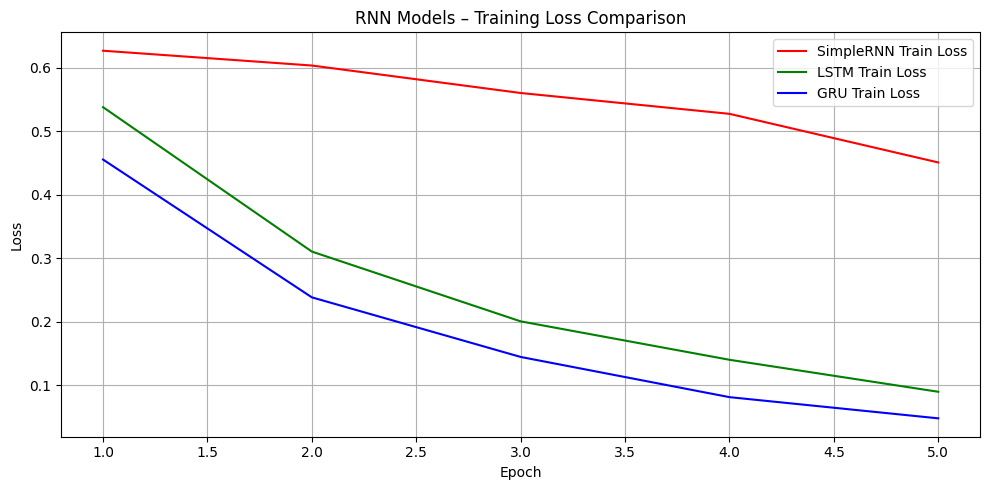

Training loss comparison plot generated.


In [28]:
# Cell 26 – Plot Training Loss comparison
import matplotlib.pyplot as plt

epochs_range = range(1, 6)
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_rnn.history['loss'],  'r', label='SimpleRNN Train Loss')
plt.plot(epochs_range, history_lstm.history['loss'], 'g', label='LSTM Train Loss')
plt.plot(epochs_range, history_gru.history['loss'],  'b', label='GRU Train Loss')
plt.title('RNN Models – Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Training loss comparison plot generated.")

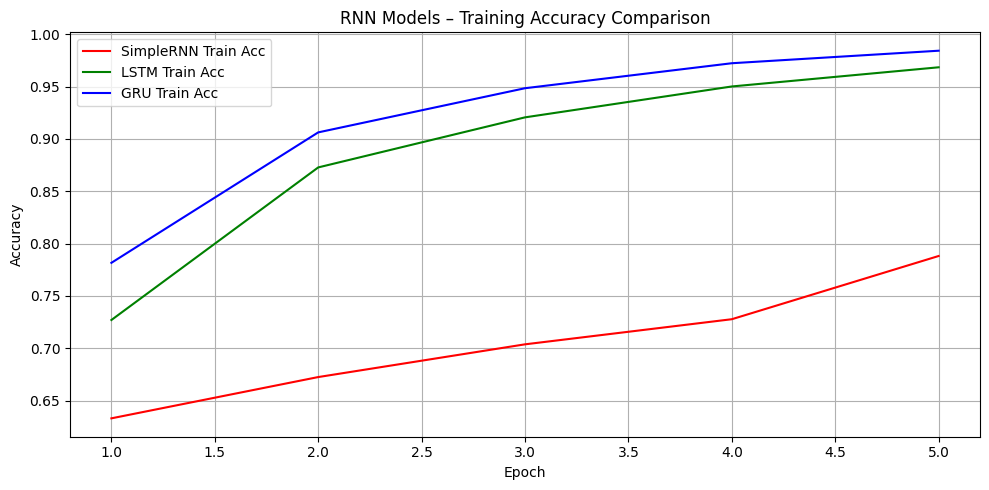

Training accuracy comparison plot generated.


In [29]:
# Cell 27 – Plot Training Accuracy comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_rnn.history['accuracy'],  'r', label='SimpleRNN Train Acc')
plt.plot(epochs_range, history_lstm.history['accuracy'], 'g', label='LSTM Train Acc')
plt.plot(epochs_range, history_gru.history['accuracy'],  'b', label='GRU Train Acc')
plt.title('RNN Models – Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Training accuracy comparison plot generated.")

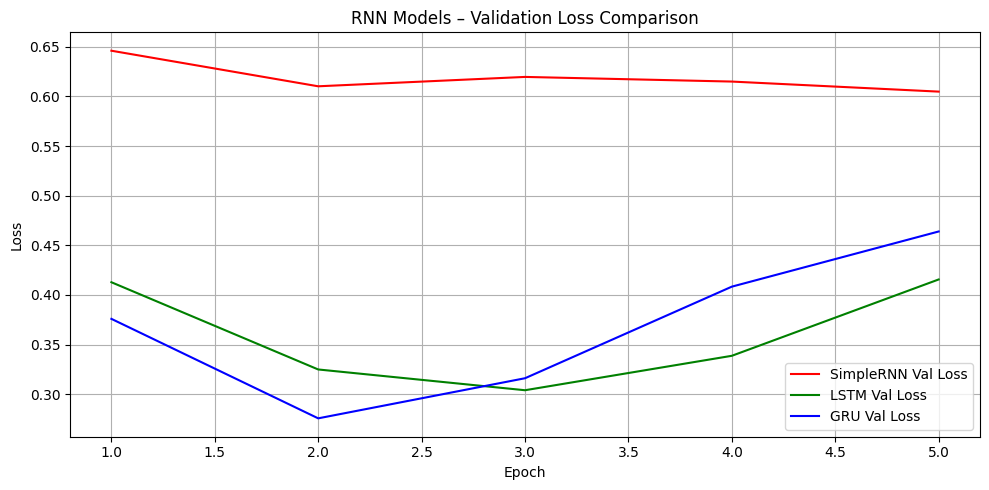

Validation loss comparison plot generated.


In [30]:
# Cell 28 – Plot Validation Loss comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_rnn.history['val_loss'],  'r', label='SimpleRNN Val Loss')
plt.plot(epochs_range, history_lstm.history['val_loss'], 'g', label='LSTM Val Loss')
plt.plot(epochs_range, history_gru.history['val_loss'],  'b', label='GRU Val Loss')
plt.title('RNN Models – Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Validation loss comparison plot generated.")

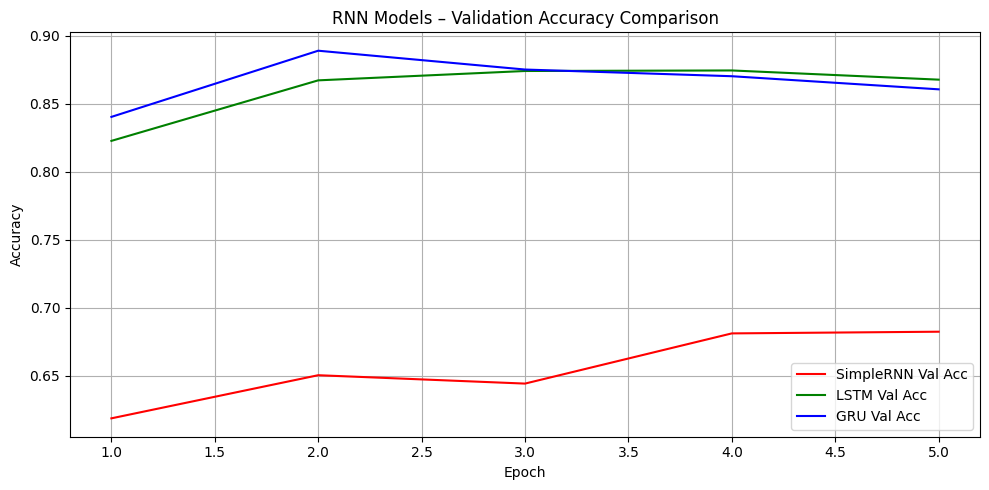

Validation accuracy comparison plot generated.


In [31]:
# Cell 29 – Plot Validation Accuracy comparison
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history_rnn.history['val_accuracy'],  'r', label='SimpleRNN Val Acc')
plt.plot(epochs_range, history_lstm.history['val_accuracy'], 'g', label='LSTM Val Acc')
plt.plot(epochs_range, history_gru.history['val_accuracy'],  'b', label='GRU Val Acc')
plt.title('RNN Models – Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Validation accuracy comparison plot generated.")

## Part 4 – Generative Adversarial Network (GAN) on Fashion-MNIST

In [32]:
# Cell 30 – Define GAN Generator
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, LeakyReLU, Reshape,
                                      BatchNormalization, Conv2DTranspose,
                                      Conv2D, Dropout, Flatten)

latent_dim = 100

def build_generator(latent_dim):
    model = Sequential(name='generator')
    # Foundation: Dense → 7×7×256
    model.add(Dense(7 * 7 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(Reshape((7, 7, 256)))
    # Upsample 7×7 → 14×14
    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    # Upsample 14×14 → 28×28
    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    # Output 28×28×1 with tanh (range [-1,1])
    model.add(Conv2D(1, (5, 5), padding='same', activation='tanh'))
    return model

generator = build_generator(latent_dim)
generator.summary()
print("Generator defined.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Generator defined.


In [33]:
# Cell 31 – Define GAN Discriminator
img_shape = (28, 28, 1)

def build_discriminator(img_shape):
    model = Sequential(name='discriminator')
    model.add(Flatten(input_shape=img_shape))
    model.add(Dense(512))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))
    model.add(Dense(256))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    return model

discriminator = build_discriminator(img_shape)
discriminator.summary()
print("Discriminator defined.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Discriminator defined.


In [34]:
# Cell 32 – Define optimisers, loss, compile discriminator
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
generator_optimizer     = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

discriminator.compile(optimizer=discriminator_optimizer,
                      loss=cross_entropy, metrics=['accuracy'])
print("Optimisers and loss function defined.")
print("Discriminator compiled.")

Optimisers and loss function defined.
Discriminator compiled.


In [35]:
# Cell 33 – Load & prepare Fashion-MNIST for GAN (TensorFlow)
(gan_images, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

gan_images = gan_images.reshape(-1, 28, 28, 1).astype('float32')
gan_images = (gan_images - 127.5) / 127.5   # normalise to [-1, 1]

batch_size_gan   = 128
train_dataset_gan = (tf.data.Dataset.from_tensor_slices(gan_images)
                       .shuffle(60000)
                       .batch(batch_size_gan, drop_remainder=True))

print(f"GAN dataset: {gan_images.shape[0]} images, batch size {batch_size_gan}")
print("Fashion-MNIST prepared for GAN training.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
GAN dataset: 60000 images, batch size 128
Fashion-MNIST prepared for GAN training.


In [36]:
# Cell 34 – Training step & train_gan function

import matplotlib.pyplot as plt
import numpy as np

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch}', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()

# Warm-up forward pass so trainable_variables are populated before tf.function tracing
_ = discriminator(tf.zeros([1, 28, 28, 1]))
_ = generator(tf.zeros([1, latent_dim]))

@tf.function
def train_step(images):
    noise = tf.random.normal([batch_size_gan, latent_dim])

    with tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output      = discriminator(images,           training=True)
        fake_output      = discriminator(generated_images, training=True)

        d_loss_real = cross_entropy(tf.ones_like(real_output),  real_output)
        d_loss_fake = cross_entropy(tf.zeros_like(fake_output), fake_output)
        d_loss      = d_loss_real + d_loss_fake

    grads_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(
        zip(grads_disc, discriminator.trainable_variables))

    noise2 = tf.random.normal([batch_size_gan, latent_dim])
    with tf.GradientTape() as gen_tape:
        fake_imgs    = generator(noise2, training=True)
        fake_preds   = discriminator(fake_imgs, training=False)
        g_loss       = cross_entropy(tf.ones_like(fake_preds), fake_preds)

    grads_gen = gen_tape.gradient(g_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(
        zip(grads_gen, generator.trainable_variables))

    real_acc = tf.reduce_mean(tf.cast(real_output > 0.5, tf.float32))
    fake_acc = tf.reduce_mean(tf.cast(fake_output < 0.5, tf.float32))
    d_acc    = (real_acc + fake_acc) / 2.0

    return d_loss, g_loss, d_acc


def train_gan(dataset, epochs, sample_interval=10):
    d_losses, g_losses, d_accuracies = [], [], []
    seed = tf.random.normal([16, latent_dim])

    for epoch in range(1, epochs + 1):
        ep_d  = tf.keras.metrics.Mean()
        ep_g  = tf.keras.metrics.Mean()
        ep_da = tf.keras.metrics.Mean()

        for batch in dataset:
            d_l, g_l, d_a = train_step(batch)
            ep_d.update_state(d_l)
            ep_g.update_state(g_l)
            ep_da.update_state(d_a)

        d_losses.append(ep_d.result().numpy())
        g_losses.append(ep_g.result().numpy())
        d_accuracies.append(ep_da.result().numpy())

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"D_loss={ep_d.result():.4f}  G_loss={ep_g.result():.4f}  "
              f"D_acc={ep_da.result():.4f}")

        if epoch % sample_interval == 0:
            generate_and_save_images(generator, epoch, seed)

    return d_losses, g_losses, d_accuracies

print("train_step and train_gan functions defined.")

train_step and train_gan functions defined.


Epoch   1/30 | D_loss=1.4505  G_loss=0.6301  D_acc=0.5168
Epoch   2/30 | D_loss=1.3628  G_loss=0.6222  D_acc=0.5679
Epoch   3/30 | D_loss=1.3811  G_loss=0.6401  D_acc=0.5465
Epoch   4/30 | D_loss=1.3885  G_loss=0.6465  D_acc=0.5345
Epoch   5/30 | D_loss=1.3897  G_loss=0.6579  D_acc=0.5255
Epoch   6/30 | D_loss=1.3880  G_loss=0.6655  D_acc=0.5258
Epoch   7/30 | D_loss=1.3881  G_loss=0.6681  D_acc=0.5250
Epoch   8/30 | D_loss=1.3871  G_loss=0.6742  D_acc=0.5227
Epoch   9/30 | D_loss=1.3881  G_loss=0.6779  D_acc=0.5197
Epoch  10/30 | D_loss=1.3861  G_loss=0.6830  D_acc=0.5222


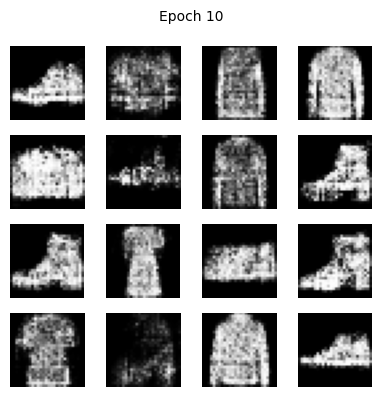

Epoch  11/30 | D_loss=1.3866  G_loss=0.6867  D_acc=0.5205
Epoch  12/30 | D_loss=1.3862  G_loss=0.6899  D_acc=0.5203
Epoch  13/30 | D_loss=1.3860  G_loss=0.6894  D_acc=0.5197
Epoch  14/30 | D_loss=1.3877  G_loss=0.6909  D_acc=0.5174
Epoch  15/30 | D_loss=1.3869  G_loss=0.6909  D_acc=0.5153
Epoch  16/30 | D_loss=1.3868  G_loss=0.6913  D_acc=0.5154
Epoch  17/30 | D_loss=1.3873  G_loss=0.6958  D_acc=0.5138
Epoch  18/30 | D_loss=1.3863  G_loss=0.6925  D_acc=0.5158
Epoch  19/30 | D_loss=1.3866  G_loss=0.6939  D_acc=0.5139
Epoch  20/30 | D_loss=1.3868  G_loss=0.6967  D_acc=0.5111


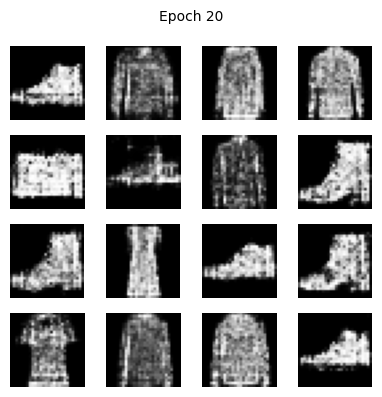

Epoch  21/30 | D_loss=1.3867  G_loss=0.6936  D_acc=0.5102
Epoch  22/30 | D_loss=1.3868  G_loss=0.6953  D_acc=0.5104
Epoch  23/30 | D_loss=1.3862  G_loss=0.6970  D_acc=0.5107
Epoch  24/30 | D_loss=1.3863  G_loss=0.6976  D_acc=0.5088
Epoch  25/30 | D_loss=1.3863  G_loss=0.6966  D_acc=0.5116
Epoch  26/30 | D_loss=1.3863  G_loss=0.6978  D_acc=0.5103
Epoch  27/30 | D_loss=1.3862  G_loss=0.6968  D_acc=0.5102
Epoch  28/30 | D_loss=1.3859  G_loss=0.6972  D_acc=0.5114
Epoch  29/30 | D_loss=1.3869  G_loss=0.6988  D_acc=0.5059
Epoch  30/30 | D_loss=1.3865  G_loss=0.6970  D_acc=0.5083


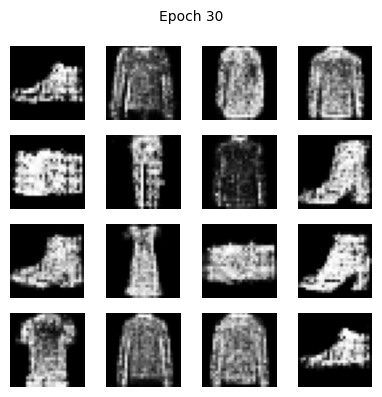

GAN training complete. Metrics stored.


In [37]:
# Cell 35 – Train GAN (30 epochs)
gan_epochs = 30
d_losses_gan, g_losses_gan, d_accuracies_gan = train_gan(
    train_dataset_gan, epochs=gan_epochs, sample_interval=10)
print("GAN training complete. Metrics stored.")

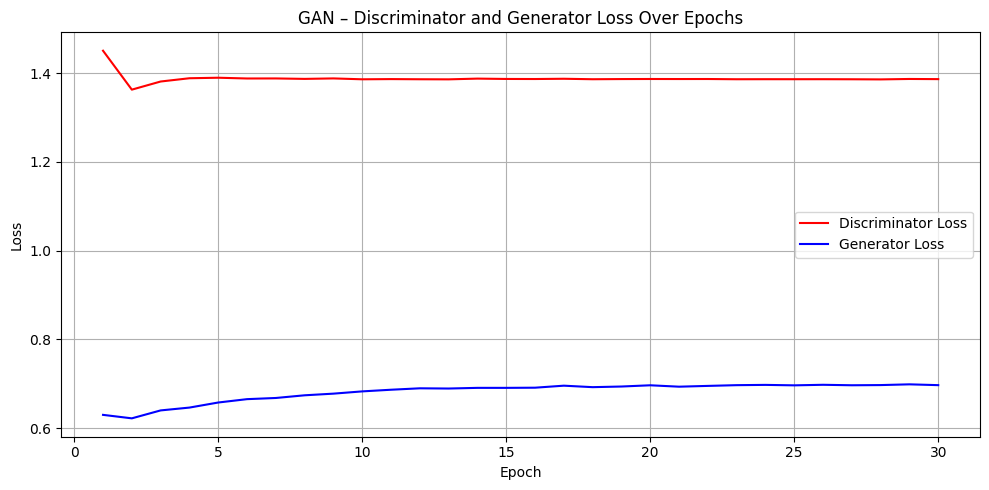

GAN loss plot generated.


In [38]:
# Cell 36 – Plot GAN discriminator & generator losses
epochs_gan = range(1, len(d_losses_gan) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_gan, d_losses_gan, 'r', label='Discriminator Loss')
plt.plot(epochs_gan, g_losses_gan, 'b', label='Generator Loss')
plt.title('GAN – Discriminator and Generator Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("GAN loss plot generated.")

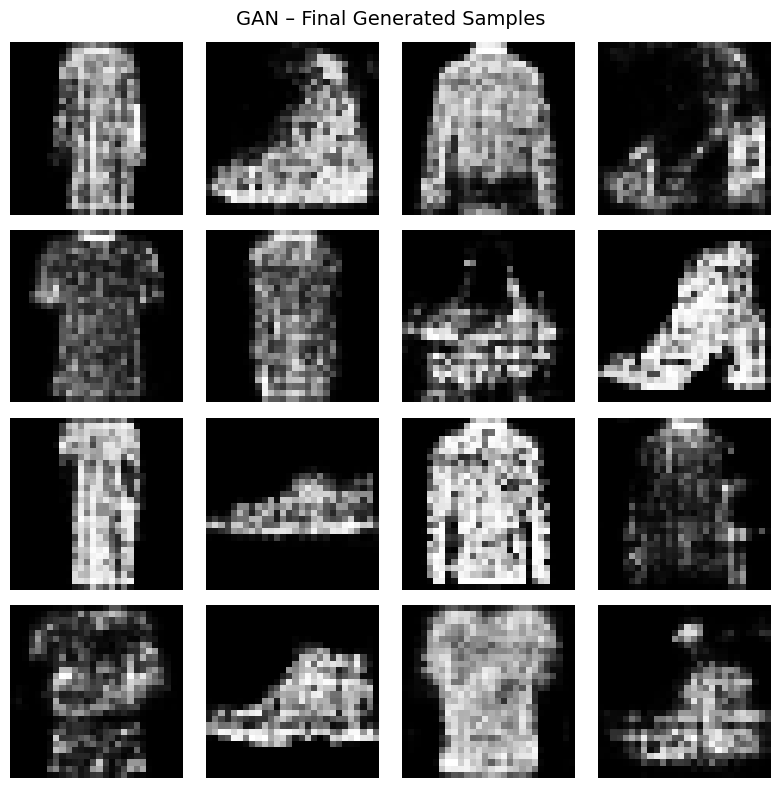

Final GAN samples saved as 'gan_final_samples.png'.


In [39]:
# Cell 37 – Display final generated images
seed_final = tf.random.normal([16, latent_dim])
predictions = generator(seed_final, training=False)

fig = plt.figure(figsize=(8, 8))
fig.suptitle('GAN – Final Generated Samples', fontsize=14)
for i in range(predictions.shape[0]):
    plt.subplot(4, 4, i + 1)
    plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.savefig('gan_final_samples.png')
plt.show()
print("Final GAN samples saved as 'gan_final_samples.png'.")